# Feature Engineering - Historical Averages with Blocked CV

This notebook covers all feature engineering steps.

For now, data will be taken from an interim csv file, where the data is stored right after loading from DB.

This solution is used only for exploration purposes. If engineered features are useful for the model, they will be introduced as a part of a standard data processing pipeline.

## Steps covered:
- Data loading from csv
- Feature engineering:
    - route - added in 01_EDA
    - pax_bin - the same approach as in EDA will be used: min, 100, 150, 180, max - added in 01_EDA
    - **average historical sales features (using blocked cross-validation)**
- Hierarchical aggregation with 3 levels:
    1. item_id × route × day_period
    2. item_id × route × is_night
    3. item_id × day_period
- Storing the data into csv

Features that do not demonstrate predictive signal will be excluded from the final pipeline.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

pd.set_option('display.max_rows', None)

In [13]:
df = pd.read_csv("interim_for_notebooks/df.csv", parse_dates=['date'])
print(f"Columns: {df.columns.tolist()}")
print(f"\nTotal records: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days}")

Columns: ['Unnamed: 0', 'flight_key', 'flight_number', 'origin', 'destination', 'date', 'month_name', 'year', 'weekday_name', 'is_weekend', 'hour_of_departure', 'day_period', 'is_night', 'am_pm', 'number_of_passengers', 'item_id', 'category', 'price', 'sold_quantity', 'potential_error', 'route', 'pax_bin', 'price_bin']

Total records: 53881
Date range: 2025-11-01 00:00:00 to 2026-02-28 00:00:00
Total days: 119


## 1. Hierarchical Aggregation Level Analysis

Before implementing the full CV pipeline, let's analyze the coverage and data availability at each aggregation level.

Level 1: item_id × route × day_period
- **Risk**: Not enough records for rare combinations
- **Advantage**: Most specific - captures route-specific and time-of-day patterns

In [14]:
item_route_day_df = df.groupby(["item_id", "route", "day_period"])["sold_quantity"].agg(["mean", "sum", "count"])

total_groups = len(item_route_day_df)
groups_below_5 = len(item_route_day_df[item_route_day_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 1: item_id × route × day_period")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 10: {groups_below_5}")
print(f"  Percentage below 10: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥10 samples: {100 - percent_below_5:.2f}%")

Level 1: item_id × route × day_period
  Total groups: 1146
  Groups with count < 10: 325
  Percentage below 10: 28.36%
  → Coverage with ≥10 samples: 71.64%


**Conclusion**: A combination of item_id, route, day_period provides enough datapoints for ~66% of unique combinations in the dataset which have at least 10 records.

Level 2: item_id × route × is_night
- **Risk**: Less granular than day_period
- **Advantage**: Better coverage, useful fallback when Level 1 has insufficient data

In [15]:
item_route_night_df = df.groupby(["item_id", "route", "is_night"])["sold_quantity"].agg(["mean", "sum", "count"])

total_groups = len(item_route_night_df)
groups_below_5 = len(item_route_night_df[item_route_night_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 2: item_id × route × is_night")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 10: {groups_below_5}")
print(f"  Percentage below 10: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥10 samples: {100 - percent_below_5:.2f}%")

Level 2: item_id × route × is_night
  Total groups: 708
  Groups with count < 10: 86
  Percentage below 10: 12.15%
  → Coverage with ≥10 samples: 87.85%


**Conclusion**: A combination of item_id, route, is_night provides enough datapoints for ~81.5% of unique combinations in the dataset which have at least 10 records.

Level 3: item_id × day_period
- **Risk**: Loses route-specific signal
- **Advantage**: 100% coverage, useful for new routes or very rare combinations

In [16]:
item_day_period_df = df.groupby(["item_id", "day_period"])["sold_quantity"].agg(["mean", "sum", "count"])

total_groups = len(item_day_period_df)
groups_below_5 = len(item_day_period_df[item_day_period_df['count'] < 5])
percent_below_5 = (groups_below_5 / total_groups * 100)

print(f"Level 3: item_id × day_periodt")
print(f"  Total groups: {total_groups}")
print(f"  Groups with count < 10: {groups_below_5}")
print(f"  Percentage below 10: {percent_below_5:.2f}%")
print(f"  → Coverage with ≥10 samples: {100 - percent_below_5:.2f}%")

Level 3: item_id × day_periodt
  Total groups: 36
  Groups with count < 10: 0
  Percentage below 10: 0.00%
  → Coverage with ≥10 samples: 100.00%


**Conclusion**: A combination of item_id, day_period provides enough datapoints for 100% of unique combinations in the dataset which have at least 10 records.

## 2. Blocked Cross-Validation Setup

**Strategy**: Expanding window cross-validation with 14-day validation blocks.

**Logic**:
- First 14 days (2025-11-01 to 2025-11-14) used as initial training set
- Each fold validates on next 14-day block
- Training window expands with each fold (includes all previous data)
- Last fold may be partial if remaining data < 14 days
- Ensures no data leakage: features computed only from past data

In [17]:
def create_blocked_cv_folds(df, block_size_days=14):
    """
    Create blocked cross-validation folds with expanding window.
    Includes last partial fold if remaining data exists.
    
    Parameters:
    -----------
    df : DataFrame
        Data with 'date' column
    block_size_days : int
        Size of each validation block in days (default: 14)
    
    Returns:
    --------
    list of fold dictionaries
    """
    df = df.sort_values('date').reset_index(drop=True)
    min_date = df['date'].min()
    max_date = df['date'].max()
    
    folds = []
    current_date = min_date
    
    while current_date < max_date:
        # Define validation block
        val_start = current_date
        val_end = min(current_date + timedelta(days=block_size_days), max_date + timedelta(days=1))
        
        # Train on all data before validation block
        train_mask = df['date'] < val_start
        val_mask = (df['date'] >= val_start) & (df['date'] < val_end)
        
        # Only create fold if we have training data and validation data
        if train_mask.sum() > 0 and val_mask.sum() > 0:
            folds.append({
                'fold_num': len(folds) + 1,
                'train_start': df[train_mask]['date'].min(),
                'train_end': df[train_mask]['date'].max(),
                'val_start': val_start,
                'val_end': val_end - timedelta(days=1),
                'train_indices': df[train_mask].index.tolist(),
                'val_indices': df[val_mask].index.tolist(),
                'train_size': train_mask.sum(),
                'val_size': val_mask.sum()
            })
        
        # Move to next block
        current_date += timedelta(days=block_size_days)
    
    return folds

In [18]:
# Create folds
folds = create_blocked_cv_folds(df, block_size_days=14)

print(f"\nCreated {len(folds)} folds from dataframe:")
print("="*100)
for fold in folds:
    print(f"Fold {fold['fold_num']}: Train [{fold['train_start'].date()} to {fold['train_end'].date()}] "
          f"→ Val [{fold['val_start'].date()} to {fold['val_end'].date()}] | "
          f"Train size: {fold['train_size']}, Val size: {fold['val_size']}")


Created 8 folds from dataframe:
Fold 1: Train [2025-11-01 to 2025-11-14] → Val [2025-11-15 to 2025-11-28] | Train size: 6126, Val size: 6236
Fold 2: Train [2025-11-01 to 2025-11-28] → Val [2025-11-29 to 2025-12-12] | Train size: 12362, Val size: 6427
Fold 3: Train [2025-11-01 to 2025-12-12] → Val [2025-12-13 to 2025-12-26] | Train size: 18789, Val size: 6400
Fold 4: Train [2025-11-01 to 2025-12-26] → Val [2025-12-27 to 2026-01-09] | Train size: 25189, Val size: 6454
Fold 5: Train [2025-11-01 to 2026-01-09] → Val [2026-01-10 to 2026-01-23] | Train size: 31643, Val size: 6373
Fold 6: Train [2025-11-01 to 2026-01-23] → Val [2026-01-24 to 2026-02-06] | Train size: 38016, Val size: 6282
Fold 7: Train [2025-11-01 to 2026-02-06] → Val [2026-02-07 to 2026-02-20] | Train size: 44298, Val size: 6075
Fold 8: Train [2025-11-01 to 2026-02-20] → Val [2026-02-21 to 2026-02-28] | Train size: 50373, Val size: 3508


## 3. Hierarchical Feature Engineering Function

**Objective**: Compute historical average sales for each record using hierarchical aggregation.

**Hierarchy (from most to least granular)**:
1. **Level 1**: item_id × route × day_period (most specific)
2. **Level 2**: item_id × route × is_night (fallback if L1 has <10 samples)
3. **Level 3**: item_id × day_period (broadest fallback, 100% coverage)

**Output**:
- `hist_avg`: single feature with historical average value
- `hist_level_used`: indicator (1, 2, or 3) showing which level was used

In [19]:
def compute_hierarchical_historical_avg(train_df, val_df, min_samples=5):
    """
    Compute hierarchical historical average for validation set.
    
    Parameters:
    -----------
    train_df : DataFrame
        Training data
    val_df : DataFrame
        Validation data
    min_samples : int
        Minimum samples required at each level to use that average
    
    Returns:
    --------
    DataFrame with historical average features added
    """
    val_df = val_df.copy()
    
    # Level 1: item_id × route × day_period
    level1_avg = train_df.groupby(['item_id', 'route', 'day_period']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level1_avg.columns = ['hist_avg_l1', 'hist_count_l1']
    level1_avg = level1_avg.reset_index()
    
    # Level 2: item_id × route × is_night
    level2_avg = train_df.groupby(['item_id', 'route', 'is_night']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level2_avg.columns = ['hist_avg_l2', 'hist_count_l2']
    level2_avg = level2_avg.reset_index()
    
    # Level 3: item_id × day_period
    level3_avg = train_df.groupby(['item_id', 'day_period']).agg({
        'sold_quantity': ['mean', 'count']
    })
    level3_avg.columns = ['hist_avg_l3', 'hist_count_l3']
    level3_avg = level3_avg.reset_index()
    
    # Merge all levels
    val_df = val_df.merge(level1_avg, on=['item_id', 'route', 'day_period'], how='left')
    val_df = val_df.merge(level2_avg, on=['item_id', 'route', 'is_night'], how='left')
    val_df = val_df.merge(level3_avg, on=['item_id', 'day_period'], how='left')
    
    # Apply hierarchical logic
    val_df['hist_avg'] = np.nan
    val_df['hist_level_used'] = np.nan
    
    # Use Level 1 if count >= min_samples
    mask_l1 = (val_df['hist_count_l1'] >= min_samples)
    val_df.loc[mask_l1, 'hist_avg'] = val_df.loc[mask_l1, 'hist_avg_l1']
    val_df.loc[mask_l1, 'hist_level_used'] = 1
    
    # Fall back to Level 2 where Level 1 unavailable
    mask_l2 = (val_df['hist_avg'].isna()) & (val_df['hist_count_l2'] >= min_samples)
    val_df.loc[mask_l2, 'hist_avg'] = val_df.loc[mask_l2, 'hist_avg_l2']
    val_df.loc[mask_l2, 'hist_level_used'] = 2
    
    # Fall back to Level 3 where Level 2 unavailable
    mask_l3 = (val_df['hist_avg'].isna()) & (val_df['hist_count_l3'] >= min_samples)
    val_df.loc[mask_l3, 'hist_avg'] = val_df.loc[mask_l3, 'hist_avg_l3']
    val_df.loc[mask_l3, 'hist_level_used'] = 3
    
    # Calculate coverage
    coverage = (~val_df['hist_avg'].isna()).sum() / len(val_df) * 100
    level_usage = val_df['hist_level_used'].value_counts().sort_index()
    
    return val_df, coverage, level_usage

## 4. Apply Features to All CV Folds

Loop through all folds, compute hierarchical features, and track:
- Coverage % (records with features)
- Level usage distribution per fold
- Add `fold_num` column to track which fold each record belongs to

In [20]:
# Apply hierarchical historical averages to all CV folds
results = []
all_val_dfs = []

for fold in folds:
    train_indices = fold['train_indices']
    val_indices = fold['val_indices']
    
    train_df = df.iloc[train_indices]
    val_df = df.iloc[val_indices]
    
    # Compute features
    val_with_features, coverage, level_usage = compute_hierarchical_historical_avg(
        train_df, val_df, min_samples=5
    )
    
    # Add fold number column
    val_with_features['fold_num'] = fold['fold_num']
    
    # Store results
    results.append({
        'fold_num': fold['fold_num'],
        'coverage': coverage,
        'level_usage': level_usage
    })
    
    all_val_dfs.append(val_with_features)
    
    print(f"Fold {fold['fold_num']}: Coverage = {coverage:.2f}%")
    print(f"  Level usage: {level_usage.to_dict()}")
    print()

# Concatenate all folds into one dataframe
all_folds_data = pd.concat(all_val_dfs, ignore_index=True)
print(f"\nComplete CV dataset shape: {all_folds_data.shape}")
print(f"Date range: {all_folds_data['date'].min().date()} to {all_folds_data['date'].max().date()}")

Fold 1: Coverage = 100.00%
  Level usage: {1.0: 5225, 2.0: 480, 3.0: 531}

Fold 2: Coverage = 100.00%
  Level usage: {1.0: 6220, 2.0: 110, 3.0: 97}

Fold 3: Coverage = 100.00%
  Level usage: {1.0: 6226, 2.0: 75, 3.0: 99}

Fold 4: Coverage = 100.00%
  Level usage: {1.0: 6362, 2.0: 41, 3.0: 51}

Fold 5: Coverage = 100.00%
  Level usage: {1.0: 6268, 2.0: 72, 3.0: 33}

Fold 6: Coverage = 100.00%
  Level usage: {1.0: 6197, 2.0: 65, 3.0: 20}

Fold 7: Coverage = 100.00%
  Level usage: {1.0: 5971, 2.0: 62, 3.0: 42}

Fold 8: Coverage = 100.00%
  Level usage: {1.0: 3447, 2.0: 48, 3.0: 13}


Complete CV dataset shape: (47755, 32)
Date range: 2025-11-01 to 2026-02-28


## 5. Feature Quality Visualization

Four-panel visualization showing:
1. **Coverage by Fold**: Feature availability % per fold (target: >90%)
2. **Hierarchy Level Usage**: Total usage count for each aggregation level
3. **Level Distribution by Fold**: Stacked bars showing level usage evolution across folds
4. **Coverage Trend**: Line chart tracking coverage stability over time

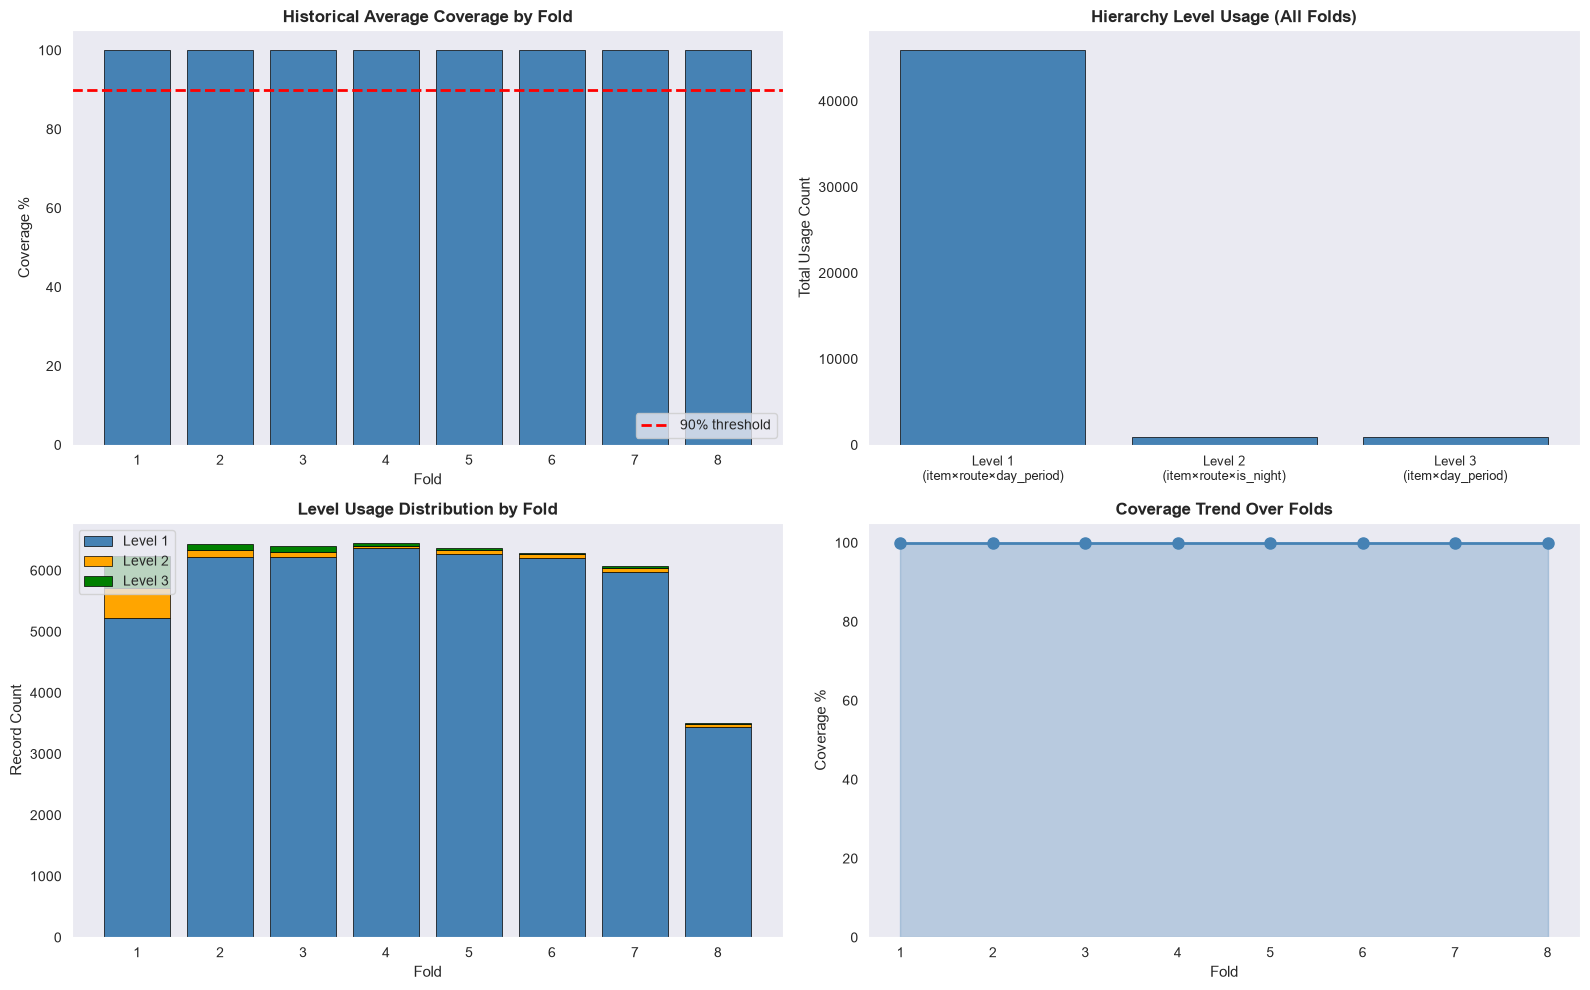


Visualization saved to: assests/feature_quality_analysis.png


In [21]:
# Feature Quality Analysis - Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Historical Average Coverage by Fold (top left)
ax1 = axes[0, 0]
coverage_by_fold = [r['coverage'] for r in results]
folds_list = [r['fold_num'] for r in results]
ax1.bar(folds_list, coverage_by_fold, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.axhline(y=90, color='red', linestyle='--', linewidth=2, label='90% threshold')
ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('Coverage %', fontsize=11)
ax1.set_title('Historical Average Coverage by Fold', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 105])
ax1.legend(loc='lower right')
ax1.grid(False)

# 2. Hierarchy Level Usage - All Folds (top right)
ax2 = axes[0, 1]
level_counts = all_folds_data['hist_level_used'].value_counts().sort_index()
labels = [f'Level {int(lvl)}\n(item×route×day_period)' if lvl == 1
          else f'Level {int(lvl)}\n(item×route×is_night)' if lvl == 2
          else f'Level {int(lvl)}\n(item×day_period)'
          for lvl in level_counts.index]
ax2.bar(range(len(level_counts)), level_counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(level_counts)))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Total Usage Count', fontsize=11)
ax2.set_title('Hierarchy Level Usage (All Folds)', fontsize=12, fontweight='bold')
ax2.grid(False)

# 3. Level Usage Distribution by Fold (bottom left)
ax3 = axes[1, 0]
# Prepare data for stacked bar chart
fold_level_data = []
for fold_num in sorted(all_folds_data['fold_num'].unique()):
    fold_data = all_folds_data[all_folds_data['fold_num'] == fold_num]
    level_dist = fold_data['hist_level_used'].value_counts().sort_index()
    fold_level_data.append({
        'fold': fold_num,
        'level_1': level_dist.get(1, 0),
        'level_2': level_dist.get(2, 0),
        'level_3': level_dist.get(3, 0)
    })

fold_level_df = pd.DataFrame(fold_level_data)
x_pos = fold_level_df['fold']
ax3.bar(x_pos, fold_level_df['level_1'], label='Level 1', color='steelblue', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_2'], bottom=fold_level_df['level_1'],
        label='Level 2', color='orange', edgecolor='black', linewidth=0.5)
ax3.bar(x_pos, fold_level_df['level_3'],
        bottom=fold_level_df['level_1'] + fold_level_df['level_2'],
        label='Level 3', color='green', edgecolor='black', linewidth=0.5)
ax3.set_xlabel('Fold', fontsize=11)
ax3.set_ylabel('Record Count', fontsize=11)
ax3.set_title('Level Usage Distribution by Fold', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(False)

# 4. Coverage Trend Over Folds (bottom right)
ax4 = axes[1, 1]
ax4.plot(folds_list, coverage_by_fold, marker='o', linewidth=2, markersize=8, color='steelblue')
ax4.fill_between(folds_list, 0, coverage_by_fold, alpha=0.3, color='steelblue')
ax4.set_xlabel('Fold', fontsize=11)
ax4.set_ylabel('Coverage %', fontsize=11)
ax4.set_title('Coverage Trend Over Folds', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 105])
ax4.grid(False)

plt.tight_layout()
plt.savefig('assests/feature_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: assests/feature_quality_analysis.png")

## 6. Save Complete Dataset

Save all CV folds with engineered features to CSV.

**Output**: `complete_data_with_features.csv` containing:
- All original columns
- `hist_avg`: historical average feature
- `hist_level_used`: aggregation level (1, 2, or 3)
- `fold_num`: cross-validation fold identifier
- Intermediate level columns (hist_avg_l1/l2/l3, hist_count_l1/l2/l3)

In [22]:
# Save complete dataset with features
all_folds_data.to_csv("interim_for_notebooks/complete_data_with_features.csv", index=False)

print(f"✓ Saved complete CV dataset with features")
print(f"  File: interim_for_notebooks/complete_data_with_features.csv")
print(f"  Shape: {all_folds_data.shape}")
print(f"  Columns: {list(all_folds_data.columns)}")
print(f"\nKey features:")
print(f"  - hist_avg: historical average feature")
print(f"  - hist_level_used: aggregation level (1, 2, or 3)")
print(f"  - fold_num: cross-validation fold number")

✓ Saved complete CV dataset with features
  File: interim_for_notebooks/complete_data_with_features.csv
  Shape: (47755, 32)
  Columns: ['Unnamed: 0', 'flight_key', 'flight_number', 'origin', 'destination', 'date', 'month_name', 'year', 'weekday_name', 'is_weekend', 'hour_of_departure', 'day_period', 'is_night', 'am_pm', 'number_of_passengers', 'item_id', 'category', 'price', 'sold_quantity', 'potential_error', 'route', 'pax_bin', 'price_bin', 'hist_avg_l1', 'hist_count_l1', 'hist_avg_l2', 'hist_count_l2', 'hist_avg_l3', 'hist_count_l3', 'hist_avg', 'hist_level_used', 'fold_num']

Key features:
  - hist_avg: historical average feature
  - hist_level_used: aggregation level (1, 2, or 3)
  - fold_num: cross-validation fold number
